In [ ]:
!pip install igor2

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from igor2 import binarywave as bw
import glob
import pickle
from pathlib import Path
from matplotlib.transforms import Bbox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
import re
from scipy.interpolate import RBFInterpolator

In [ ]:
from scipy.fftpack import fft2, ifft2, fftshift
from scipy.stats import binned_statistic
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter, maximum_filter, minimum_filter
import matplotlib.patches as patches

from scipy.spatial import Voronoi
from skimage.filters import gaussian
from skimage.feature import peak_local_max
from skimage.morphology import disk
from shapely.geometry import Polygon

In [ ]:
import warnings
warnings.filterwarnings('ignore')

##Data Preperation

In [ ]:
def flatten_image(image, order=1, axis=1):

    flattened_image = np.copy(image)

    num_lines = image.shape[axis]
    length = image.shape[1 - axis]
    x = np.arange(length)

    for i in range(num_lines):
        line = image[i, :] if axis == 0 else image[:, i]
        coeffs = np.polyfit(x, line, deg=order)
        fit_line = np.polyval(coeffs, x)

        if axis == 0:
            flattened_image[i, :] = line - fit_line
        else:
            flattened_image[:, i] = line - fit_line

    return flattened_image

def normalizer(img):
    img = np.asarray(img, dtype=float)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-12)

# Define once
red_white_blue = LinearSegmentedColormap.from_list(
    "red_white_blue",
    ["blue", "white", "red"]
)

##Grid Analysis

In [ ]:
with open("auconi_mfm_grid.pkl", "rb") as f:
    data = pickle.load(f)


print(data.keys())

dict_keys(['positions', 'images'])


In [ ]:
images = data["images"]
positions = data["positions"]

images = np.array(images[:23])
positions = np.array(positions[:23])  # overwrite the same variable

print(images.shape)
print(positions.shape)

(23, 5, 256, 256)
(23, 2)


vmin=-0.00, vcenter=0.00, vmax=0.00


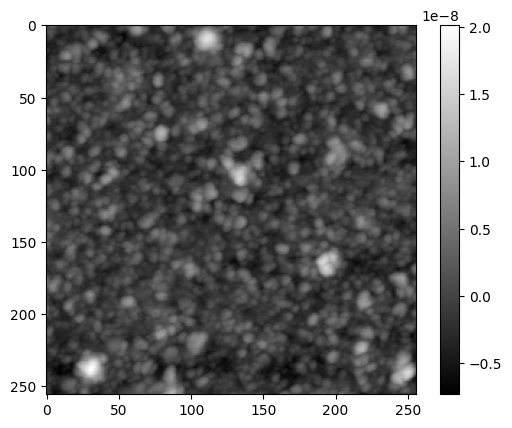

In [ ]:
slice_img = images[0][0]

vmin = np.min(slice_img)
vmax = np.max(slice_img)
vcenter = (vmin + vmax) / 2

# Create adaptive normalization
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

print(f"vmin={vmin:.2f}, vcenter={vcenter:.2f}, vmax={vmax:.2f}")

#plt.imshow(slice_img, cmap=red_white_blue, norm=norm)
plt.imshow(slice_img, cmap="gray")
plt.colorbar()
plt.show()

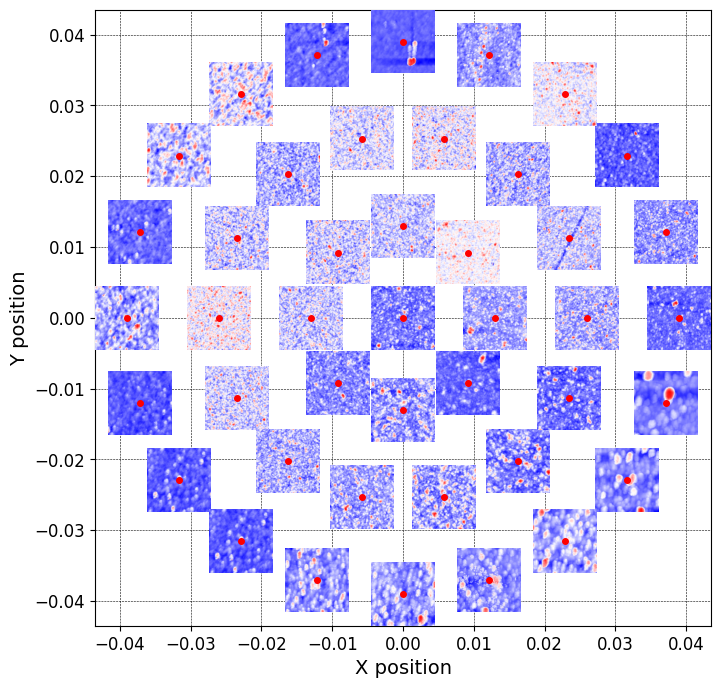

In [ ]:
channel = 0   # choose which channel to display, e.g. 0 = height, 4 = MFM
scale = 0.009   # scaling factor for image size in plot units

fig, ax = plt.subplots(figsize=(8, 8))

for img, (x, y) in zip(images, positions):
    h, w = img[channel].shape

    # extent defines where each image is placed
    extent = [x - scale/2, x + scale/2, y - scale/2, y + scale/2]

    vmin = np.min(img[channel])
    vmax = np.max(img[channel])
    vcenter = (vmin + vmax) / 2

    # Create adaptive normalization
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    #ax.imshow(img[channel], cmap="grey", extent=extent, origin="lower", zorder=5)
    ax.imshow(img[channel], cmap=red_white_blue, norm=norm, extent=extent, origin="upper", zorder=5)

    ax.plot(x, y, "ro", markersize=4, zorder=10)  # optional: mark center with red dot

ax.set_aspect("equal")
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)


ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)

#plt.savefig(out_dir / "GT_MagneticResponces_as_deposit_Realmap.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

#Correlation Length

In [ ]:
def _radial_profile(arr):
    H, W = arr.shape
    cy, cx = H//2, W//2
    y, x = np.indices(arr.shape)
    r = np.sqrt((y-cy)**2 + (x-cx)**2)
    r_flat = r.ravel()
    a_flat = arr.ravel()
    bins = np.arange(0, r_flat.max()+1)  # 1 px bins
    prof, edges, _ = binned_statistic(r_flat, a_flat, statistic='mean', bins=bins)
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, prof

def correlation_length_nm(height_img, pixel_size_nm,
                          smooth_sigma_px=3,
                          thresholds=(0.6, 0.2, 0.1)):
                            # 0.2 for mag
                            # 0.5 for hight

    I = np.asarray(height_img, dtype=float)
    if not np.isfinite(I).any():
        return np.nan

    # detrend: remove mean (you can also high-pass if there is a slow background)
    I = I - np.nanmean(I)

    # window to reduce FFT wrap-around artifacts
    wy = np.hanning(I.shape[0])[:, None]
    wx = np.hanning(I.shape[1])[None, :]
    W = wy * wx
    Iw = I * W

    # autocorrelation via Wiener–Khinchin
    F = fft2(Iw)
    P = np.abs(F)**2
    C = fftshift(np.real(ifft2(P)))

    # normalize by zero-lag value (center), not by global max
    cy, cx = C.shape[0]//2, C.shape[1]//2
    c0 = C[cy, cx]
    if not np.isfinite(c0) or c0 == 0:
        return np.nan
    Cn = C / c0

    # radial average -> C(r); smooth to suppress noise/oscillations
    r_px, Cr = _radial_profile(Cn)
    if Cr is None or not np.isfinite(Cr).any():
        return np.nan
    Cr = gaussian_filter1d(Cr, sigma=smooth_sigma_px)

    # find first crossing for any acceptable threshold
    for thr in thresholds:
        idx = np.where(Cr <= thr)[0]
        if idx.size > 0:
            i = idx[0]
            if i == 0:
                r_star_px = r_px[i]
            else:
                # linear interpolate between (i-1) and i
                y1, y2 = Cr[i-1], Cr[i]
                x1, x2 = r_px[i-1], r_px[i]
                if y2 == y1:
                    r_star_px = x2
                else:
                    t = (thr - y1)/(y2 - y1)
                    r_star_px = x1 + t*(x2 - x1)
            return float(r_star_px * pixel_size_nm)

    # no crossing found -> correlation length exceeds FOV; return NaN or FOV
    # return np.nan
    return float(min(I.shape) * pixel_size_nm)  # or comment this and return NaN

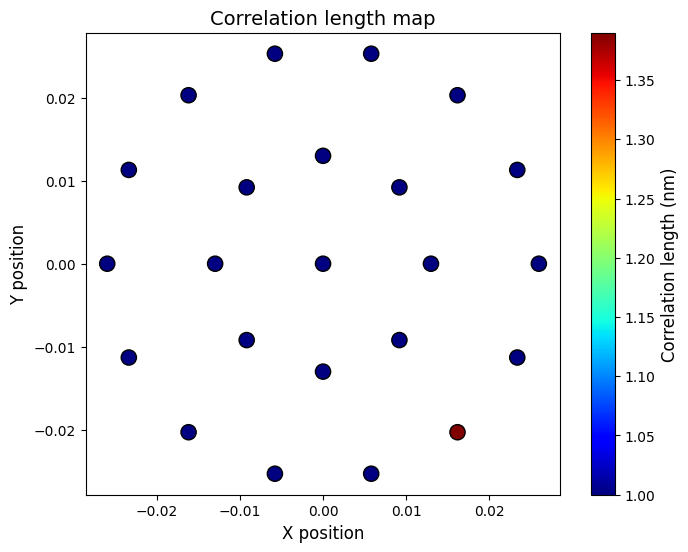

In [ ]:
# --- set parameters ---
pixel_size_nm = 2   # change to your actual calibration!
channel = 1         # 0 = height, 4 = MFM phase, etc.

correlation_lengths = []

# --- run over all images ---
for img in images:
    L = correlation_length_nm(img[channel], pixel_size_nm=pixel_size_nm)
    correlation_lengths.append(L)

correlation_lengths = np.array(correlation_lengths)

# --- plot map ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    positions[:, 0], positions[:, 1],
    c=correlation_lengths, cmap="jet",
    s=120, edgecolor="k"
)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Correlation length (nm)", fontsize=12)

ax.set_xlabel("X position", fontsize=12)
ax.set_ylabel("Y position", fontsize=12)
ax.set_title("Correlation length map", fontsize=14)
ax.set_aspect("equal")

plt.show()

In [ ]:
# Find indices of min and max correlation length
idx_max = np.nanargmax(correlation_lengths)   # ignore NaNs
idx_min = np.nanargmin(correlation_lengths)

# Values
L_max = correlation_lengths[idx_max]
L_min = correlation_lengths[idx_min]

# Corresponding positions
pos_max = positions[idx_max]
pos_min = positions[idx_min]

print(f"Max correlation length: {L_max:.2f} nm at index {idx_max}, position {pos_max}")
print(f"Min correlation length: {L_min:.2f} nm at index {idx_min}, position {pos_min}")

Max correlation length: 1.39 nm at index 21, position [ 0.0162 -0.0203]
Min correlation length: 1.00 nm at index 0, position [0. 0.]


How maxima look

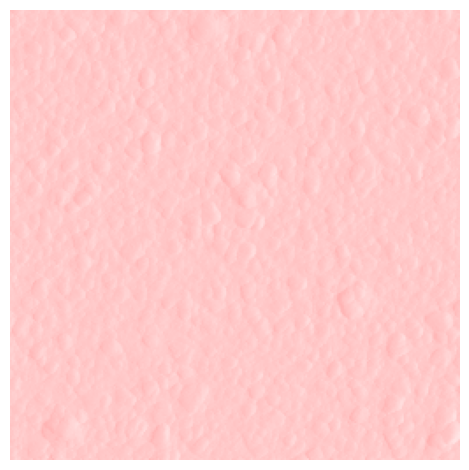

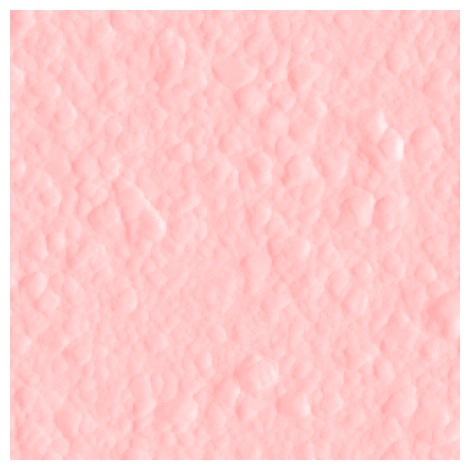

--------------------
Max corr length
1.39 nm
pos=[ 0.0162 -0.0203], idx=21
--------------------
Min corr length
1.00 nm
pos=[0. 0.], idx=0


In [ ]:
# Min image
#plt.imshow(images[idx_min][channel], cmap="grey")
plt.imshow(images[idx_min][channel], cmap=red_white_blue, norm=norm)

plt.axis("off")
# plt.savefig(out_dir / "min_mag_size_0.039 0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

# Max image
#plt.imshow(images[idx_max][channel], cmap="grey")
plt.imshow(images[idx_max][channel], cmap=red_white_blue, norm=norm)
# axes[1].set_title(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")
plt.axis("off")
# plt.savefig(out_dir / "max_mag_size_-0.039  0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

print("-" * 20)
print(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")

print("-" * 20)
print(f"Min corr length\n{L_min:.2f} nm\npos={pos_min}, idx={idx_min}")

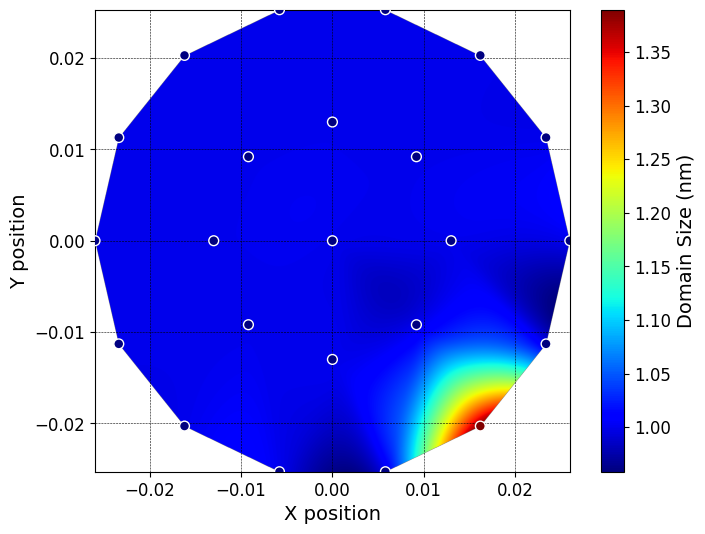

In [ ]:
# Create a regular grid covering your positions
grid_x, grid_y = np.mgrid[
    positions[:,0].min():positions[:,0].max():2000j,   # 200 points along X
    positions[:,1].min():positions[:,1].max():2000j    # 200 points along Y
]

# Interpolate values onto the grid
grid_z = griddata(positions, correlation_lengths, (grid_x, grid_y), method="cubic")

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_z.T, extent=(
        positions[:,0].min(), positions[:,0].max(),
        positions[:,1].min(), positions[:,1].max()
    ),
    origin="lower", cmap="jet", aspect="equal", zorder=1)

# Overlay measurement points
sc = ax.scatter(
    positions[:,0], positions[:,1],
    c=correlation_lengths,
    cmap="jet",
    edgecolor="w",
    s=50,
    zorder=5
)

# Colorbar
cb = plt.colorbar(im, ax=ax)
cb.set_label("Domain Size (nm)", fontsize=14)
cb.ax.tick_params(labelsize = 12)

ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)
# ax.set_title("GT_corr MAP length map", fontsize=14)
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)

#plt.savefig(out_dir / "GT_DomainSize_as_deposit.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

#Hackathon 2

#Quantitative Feauture Extraction

Purpose:
Convert raw AFM/MFM images into quantitative descriptors representing surface roughness, texture, and magnetic domain structure.

What it does:
For each AFM scan: computes roughness (Ra, Rq), skewness, kurtosis, correlation length, PSD slope, and anisotropy.
For each MFM scan: measures mean signal, contrast, edge density, and domain size.
Uses FFT-based autocorrelation (fast) and a fixed scale of 2 nm / pixel.
Output:

Feature tables (.csv) containing numeric descriptors for every scan — the foundation for clustering and regression.

In [ ]:
# === Batch AFM/MFM feature extraction over ALL scans (fixed 2 nm/pixel) ===
# Uses the same fast FFT-based internals. Saves a multi-row CSV.

import pickle, numpy as np, pandas as pd
from scipy import ndimage as ndi
from numpy.fft import fft2, ifft2, fftshift
from scipy.stats import skew, kurtosis

PKL_PATH = "/content/auconi_mfm_grid.pkl"
AFM_CH   = 0
MFM_CH   = 4
PIXEL_SIZE_NM = 2.0

# (Reuse the exact same helper + feature functions from Cell A above)
# You can copy-paste them here or import if you split into modules.

# --- paste the zscore/radial_profile/autocorr2d_fft/psd_log_slope/
#     structure_tensor_anisotropy/first_halfmax_radius/first_noncentral_peak/
#     afm_features_full/mfm_features_full definitions here ---

with open(PKL_PATH, "rb") as f:
    obj = pickle.load(f)

images    = obj["images"]
positions = obj["positions"]

rows = []
for i, arr in enumerate(images):
    afm = arr[AFM_CH]
    mfm = arr[MFM_CH]
    pos = positions[i]

    af = afm_features_full(afm)
    mf = mfm_features_full(mfm)
    row = {"idx": int(i), "pos_x": float(pos[0]), "pos_y": float(pos[1])}
    row.update(af); row.update(mf)

    # nm conversions
    row["corr_len_nm"]    = row["corr_len_px"]    * PIXEL_SIZE_NM
    row["domain_size_nm"] = row["domain_size_px"] * PIXEL_SIZE_NM

    rows.append(row)

df_features = pd.DataFrame(rows)
out_csv = "/content/afm_mfm_features_full_fixed2nm.csv"
df_features.to_csv(out_csv, index=False)
print("Saved:", out_csv)
display(df_features.head())
display(df_features.describe())


Saved: /content/afm_mfm_features_full_fixed2nm.csv


,idx,pos_x,pos_y,Ra,Rq,Skew,Kurt,corr_len_px,psd_slope,anisotropy,mfm_mean,mfm_std,edge_density,domain_size_px,corr_len_nm,domain_size_nm
0,0,0.0000,0.0000,2.130786e-09,2.874178e-09,1.454364,4.235424,5.0,-4.098701,0.359130,0.000000e+00,1.0,0.141464,58.0,10.0,116.0
1,1,0.0130,0.0000,2.180060e-09,2.951055e-09,1.399234,3.581916,5.0,-4.004037,0.345985,0.000000e+00,1.0,0.142334,45.0,10.0,90.0
2,2,0.0092,0.0092,1.523145e-09,2.034523e-09,0.924380,2.786324,4.0,-3.830884,0.308919,1.387779e-17,1.0,0.120224,41.0,8.0,82.0
3,3,0.0000,0.0130,1.490907e-09,1.921284e-09,0.523928,1.225505,4.0,-3.922130,0.327565,0.000000e+00,1.0,0.134689,37.0,8.0,74.0
4,4,-0.0092,0.0092,1.767148e-09,2.258320e-09,0.371210,0.558402,4.0,-3.952537,0.328075,6.938894e-18,1.0,0.144775,37.0,8.0,74.0


,idx,pos_x,pos_y,Ra,Rq,Skew,Kurt,corr_len_px,psd_slope,anisotropy,mfm_mean,mfm_std,edge_density,domain_size_px,corr_len_nm,domain_size_nm
count,43.000000,4.300000e+01,4.300000e+01,4.300000e+01,4.300000e+01,43.000000,43.000000,43.000000,43.000000,43.000000,4.300000e+01,4.300000e+01,43.000000,43.000000,43.000000,43.000000
mean,21.000000,1.613696e-19,8.068481e-20,2.369703e-09,3.251302e-09,1.196373,4.348646,5.976744,-3.701794,0.410642,-4.639377e-19,1.000000e+00,0.125022,39.930233,11.953488,79.860465
std,12.556539,2.216189e-02,2.215809e-02,1.647649e-09,2.471461e-09,0.913779,6.387973,2.685839,0.455483,0.091514,1.468105e-17,7.850462e-17,0.038649,14.997453,5.371678,29.994905
min,0.000000,-3.900000e-02,-3.900000e-02,8.107104e-10,1.013261e-09,0.161495,-0.000072,3.000000,-4.240974,0.301463,-4.163336e-17,1.000000e+00,0.012177,22.000000,6.000000,44.000000
25%,10.500000,-1.620000e-02,-1.665000e-02,1.321308e-09,1.826967e-09,0.592220,1.015054,4.000000,-4.001001,0.337611,-6.938894e-18,1.000000e+00,0.112572,29.000000,8.000000,58.000000
50%,21.000000,0.000000e+00,0.000000e+00,1.837825e-09,2.421775e-09,0.983502,2.151986,5.000000,-3.886712,0.374896,0.000000e+00,1.000000e+00,0.139847,37.000000,10.000000,74.000000
75%,31.500000,1.620000e-02,1.665000e-02,2.559507e-09,3.634962e-09,1.443050,4.593995,7.000000,-3.461239,0.480615,6.938894e-18,1.000000e+00,0.145683,45.000000,14.000000,90.000000
max,42.000000,3.900000e-02,3.900000e-02,8.973680e-09,1.460312e-08,4.941443,33.057441,16.000000,-2.119368,0.655581,2.775558e-17,1.000000e+00,0.184357,98.000000,32.000000,196.000000


#Exploratory Data Analysis

Purpose:
Convert raw AFM/MFM images into quantitative descriptors representing surface roughness, texture, and magnetic domain structure.

What it does:
For each AFM scan: computes roughness (Ra, Rq), skewness, kurtosis, correlation length, PSD slope, and anisotropy.
For each MFM scan: measures mean signal, contrast, edge density, and domain size.
Uses FFT-based autocorrelation (fast) and a fixed scale of 2 nm / pixel.

Output:
Feature tables (.csv) containing numeric descriptors for every scan — the foundation for clustering and regression.

Loaded: /content/afm_mfm_features_full_fixed2nm.csv  shape=(43, 16)
AFM cols: ['Ra', 'Rq', 'Skew', 'Kurt', 'corr_len_px', 'corr_len_nm', 'psd_slope', 'anisotropy']
MFM cols: ['mfm_mean', 'mfm_std', 'edge_density', 'domain_size_px', 'domain_size_nm']


,idx,pos_x,pos_y,Ra,Rq,Skew,Kurt,corr_len_px,psd_slope,anisotropy,mfm_mean,mfm_std,edge_density,domain_size_px,corr_len_nm,domain_size_nm
0,0,0.0000,0.0000,2.130786e-09,2.874178e-09,1.454364,4.235424,5.0,-4.098701,0.359130,0.000000e+00,1.0,0.141464,58.0,10.0,116.0
1,1,0.0130,0.0000,2.180060e-09,2.951055e-09,1.399234,3.581916,5.0,-4.004037,0.345985,0.000000e+00,1.0,0.142334,45.0,10.0,90.0
2,2,0.0092,0.0092,1.523145e-09,2.034523e-09,0.924380,2.786324,4.0,-3.830884,0.308919,1.387779e-17,1.0,0.120224,41.0,8.0,82.0
3,3,0.0000,0.0130,1.490907e-09,1.921284e-09,0.523928,1.225505,4.0,-3.922130,0.327565,0.000000e+00,1.0,0.134689,37.0,8.0,74.0
4,4,-0.0092,0.0092,1.767148e-09,2.258320e-09,0.371210,0.558402,4.0,-3.952537,0.328075,6.938894e-18,1.0,0.144775,37.0,8.0,74.0


,Ra,Rq,Skew,Kurt,corr_len_px,corr_len_nm,psd_slope,anisotropy,mfm_mean,mfm_std,edge_density,domain_size_px,domain_size_nm
count,4.300000e+01,4.300000e+01,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,4.300000e+01,4.300000e+01,43.000000,43.000000,43.000000
mean,2.369703e-09,3.251302e-09,1.196373,4.348646,5.976744,11.953488,-3.701794,0.410642,-4.639377e-19,1.000000e+00,0.125022,39.930233,79.860465
std,1.647649e-09,2.471461e-09,0.913779,6.387973,2.685839,5.371678,0.455483,0.091514,1.468105e-17,4.845411e-17,0.038649,14.997453,29.994905
min,8.107104e-10,1.013261e-09,0.161495,-0.000072,3.000000,6.000000,-4.240974,0.301463,-4.163336e-17,1.000000e+00,0.012177,22.000000,44.000000
25%,1.321308e-09,1.826967e-09,0.592220,1.015054,4.000000,8.000000,-4.001001,0.337611,-6.938894e-18,1.000000e+00,0.112572,29.000000,58.000000
50%,1.837825e-09,2.421775e-09,0.983502,2.151986,5.000000,10.000000,-3.886712,0.374896,0.000000e+00,1.000000e+00,0.139847,37.000000,74.000000
75%,2.559507e-09,3.634962e-09,1.443050,4.593995,7.000000,14.000000,-3.461239,0.480615,6.938894e-18,1.000000e+00,0.145683,45.000000,90.000000
max,8.973680e-09,1.460312e-08,4.941443,33.057441,16.000000,32.000000,-2.119368,0.655581,2.775558e-17,1.000000e+00,0.184357,98.000000,196.000000


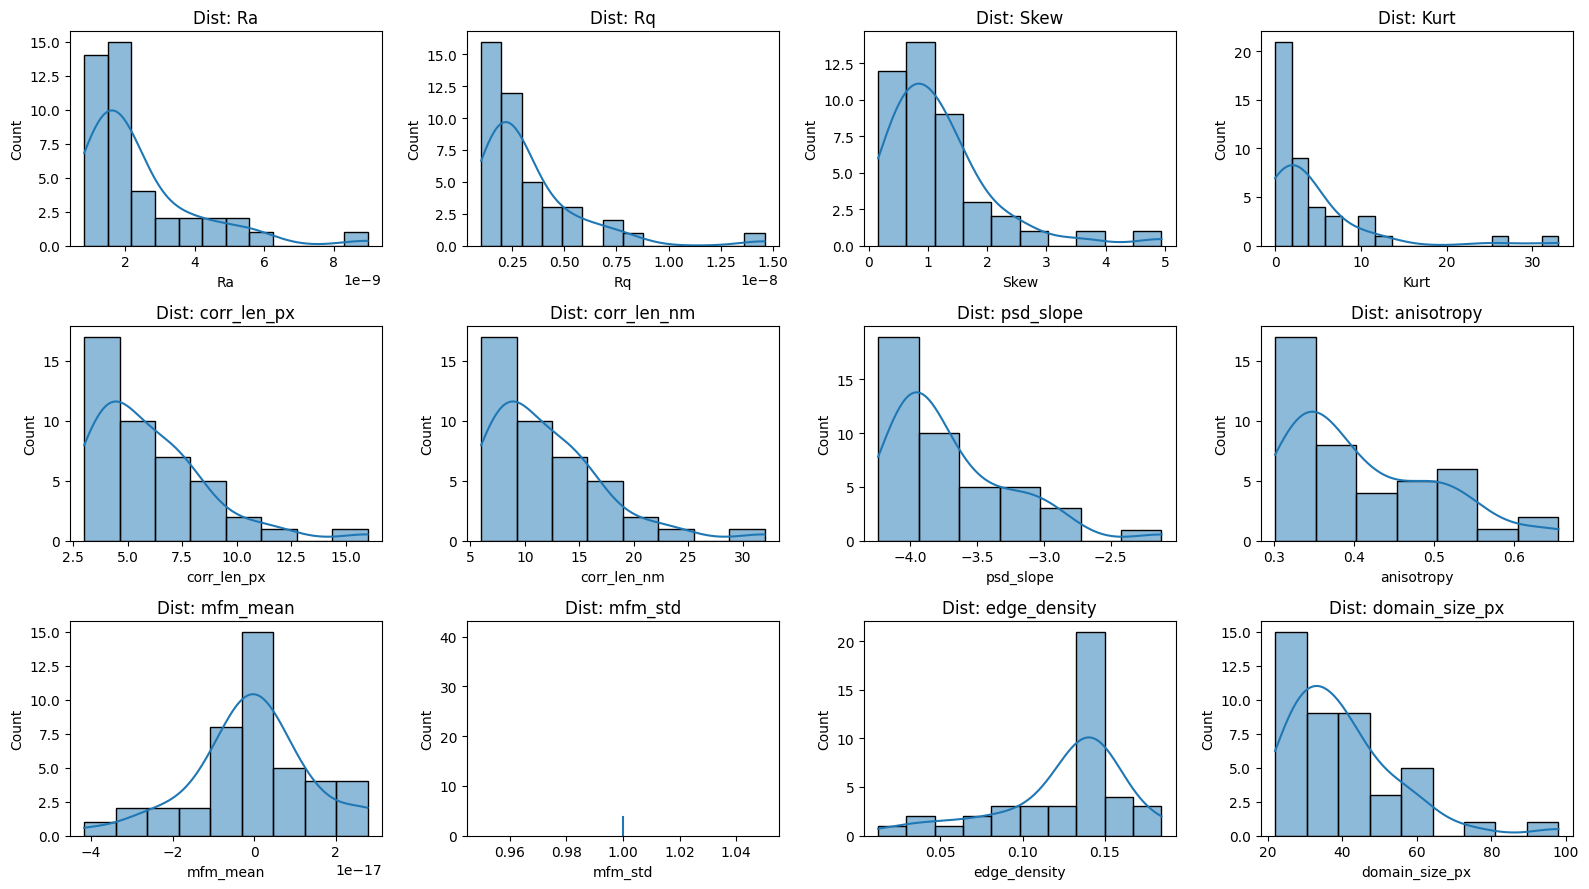

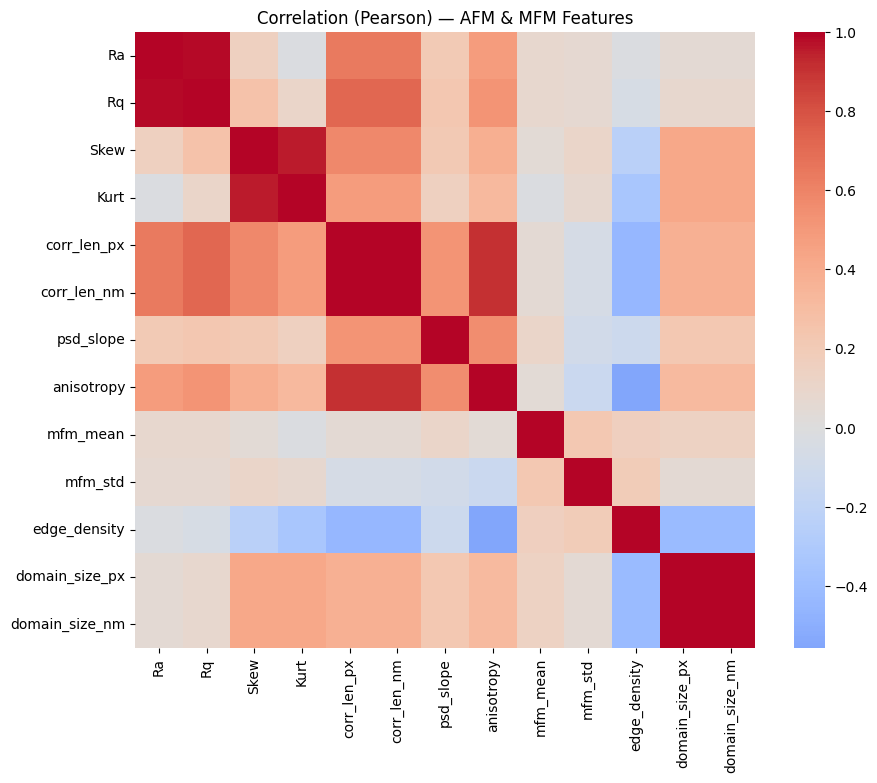

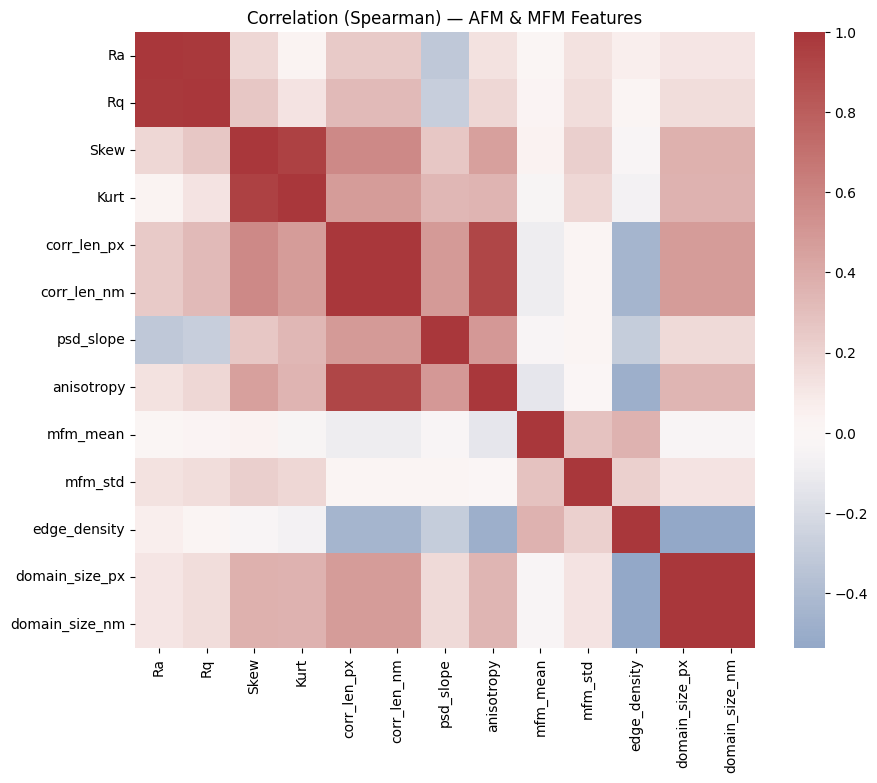

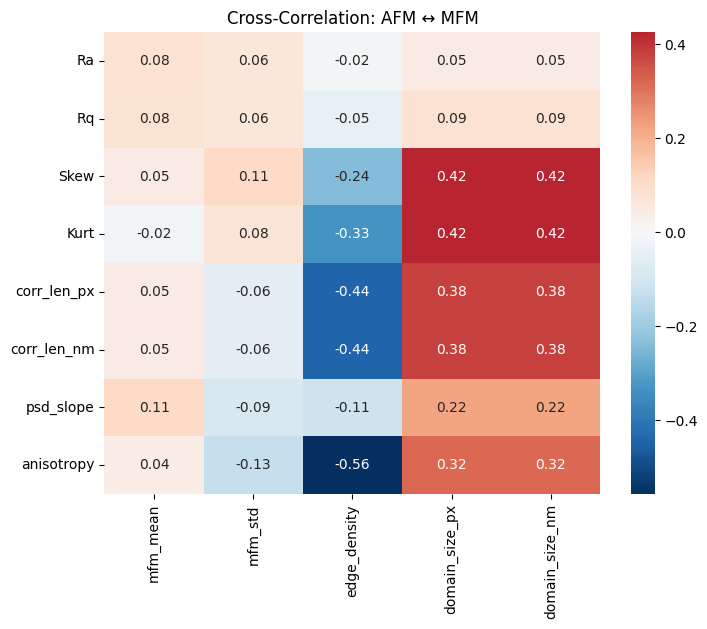

In [ ]:
# === Step 3: Exploratory Data Analysis (EDA) ===
# Works with either the batch CSV (multi-row) or a single-image CSV (one row).
# If single-row, correlation/heatmaps will be skipped automatically.

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Input: choose your CSV ----
# Prefer the batch file if you ran the “B) Batch extraction” cell
csv_path_candidates = [
    "/content/afm_mfm_features_full_fixed2nm.csv",      # batch (recommended for EDA)
]
for _p in csv_path_candidates:
    try:
        df = pd.read_csv(_p)
        print(f"Loaded: {_p}  shape={df.shape}")
        break
    except Exception:
        df = None
if df is None:
    raise FileNotFoundError("No feature CSV found. Run extraction first and set csv_path.")

# ---- Select columns ----
afm_cols = [c for c in ["Ra","Rq","Skew","Kurt","corr_len_px","corr_len_nm","psd_slope","anisotropy"] if c in df.columns]
mfm_cols = [c for c in ["mfm_mean","mfm_std","edge_density","domain_size_px","domain_size_nm"] if c in df.columns]
coord_cols = [c for c in ["pos_x","pos_y"] if c in df.columns]
all_num_cols = [c for c in afm_cols + mfm_cols if c in df.columns]

print("AFM cols:", afm_cols)
print("MFM cols:", mfm_cols)

# ---- Basic summary ----
display(df.head())
display(df[all_num_cols].describe())

# ---- Distribution plots (skip if too few rows) ----
if len(df) >= 5:
    ncols = 4
    cols_to_plot = all_num_cols[:12]  # cap for readability; adjust as needed
    nrows = int(np.ceil(len(cols_to_plot)/ncols))
    plt.figure(figsize=(4*ncols, 3*nrows))
    for i, col in enumerate(cols_to_plot, 1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(df[col].dropna(), kde=True)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Dist: {col}")
    plt.tight_layout()
    plt.show()

# ---- Correlation heatmaps (Pearson & Spearman) ----
if len(df) >= 3 and len(all_num_cols) >= 2:
    corr_p = df[all_num_cols].corr(method="pearson")
    corr_s = df[all_num_cols].corr(method="spearman")

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_p, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation (Pearson) — AFM & MFM Features")
    plt.show()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_s, cmap="vlag", center=0, annot=False)
    plt.title("Correlation (Spearman) — AFM & MFM Features")
    plt.show()

    # Focused AFM↔MFM block
    inter_afm_mfm = df[afm_cols + mfm_cols].corr().loc[afm_cols, mfm_cols]
    plt.figure(figsize=(8, 6))
    sns.heatmap(inter_afm_mfm, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Cross-Correlation: AFM ↔ MFM")
    plt.show()


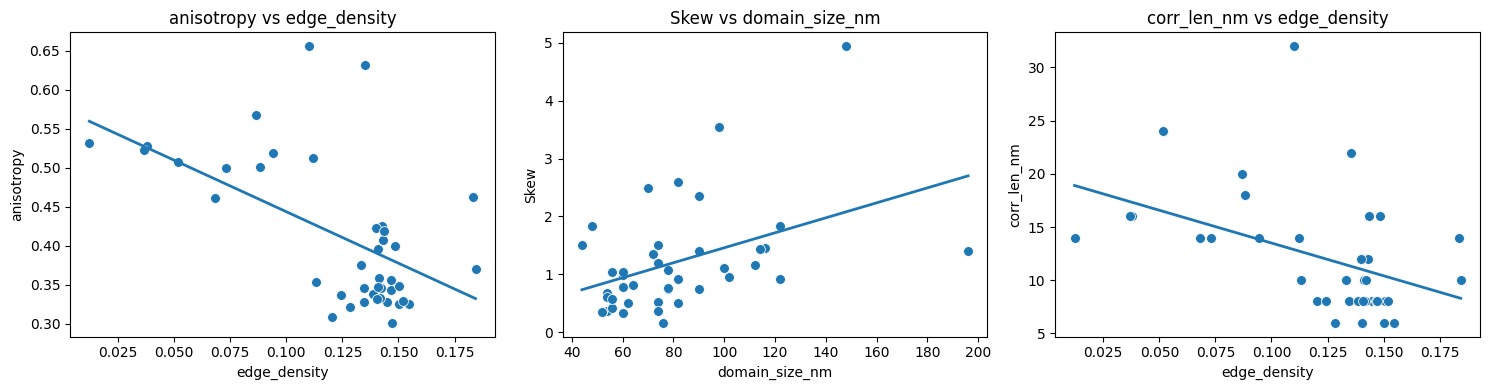

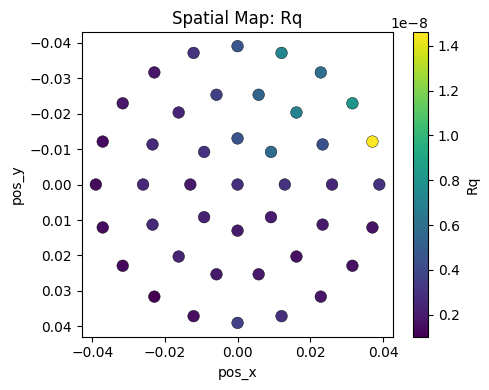

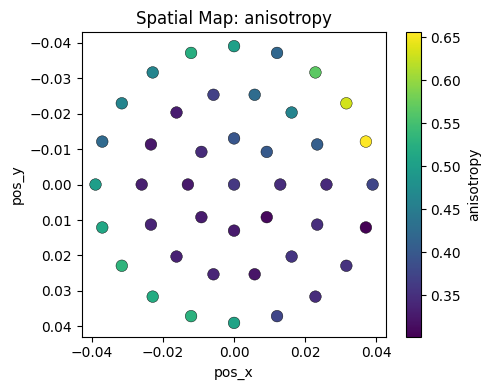

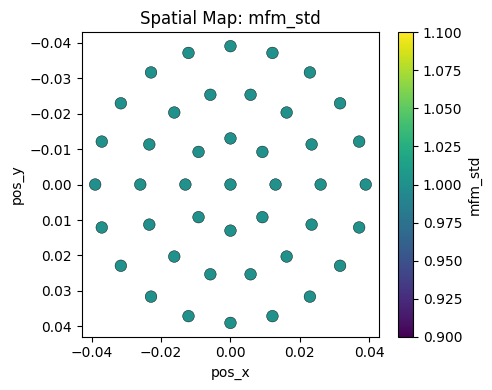

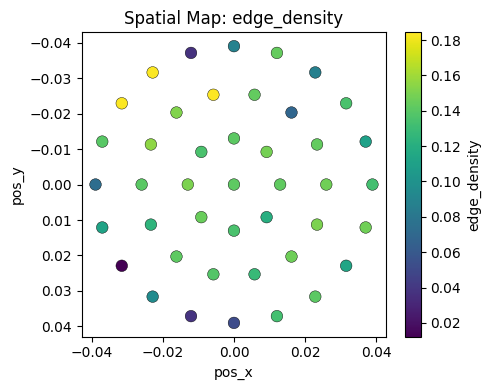

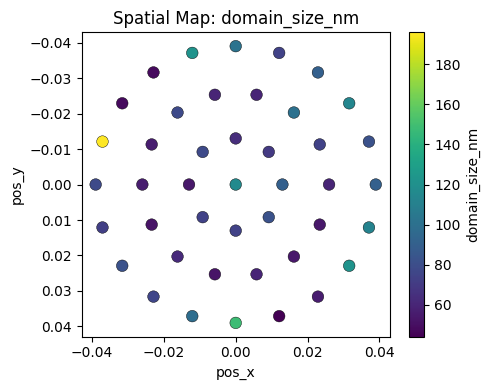

Rq vs domain_size_nm — Pearson: 0.085, Spearman: 0.151


In [ ]:
# ---- Pairwise AFM→MFM relationships (scatter) ----
pairs = []
if "edge_density" in df.columns and "anisotropy" in df.columns:
    pairs.append(("edge_density", "anisotropy"))
if "domain_size_nm" in df.columns and "Skew" in df.columns:
    pairs.append(("domain_size_nm", "Skew"))
if "edge_density" in df.columns and "corr_len_nm" in df.columns:
    pairs.append(("edge_density", "corr_len_nm"))

if len(pairs) > 0 and len(df) >= 3:
    plt.figure(figsize=(5*len(pairs), 4))
    for i, (xcol, ycol) in enumerate(pairs, 1):
        plt.subplot(1, len(pairs), i)
        sns.scatterplot(x=df[xcol], y=df[ycol], s=50)
        # add a simple linear trendline without seaborn's regplot extras
        if df[[xcol, ycol]].dropna().shape[0] >= 3:
            X = df[xcol].values
            Y = df[ycol].values
            mask = np.isfinite(X) & np.isfinite(Y)
            if np.count_nonzero(mask) >= 3:
                a, b = np.polyfit(X[mask], Y[mask], 1)
                xs = np.linspace(np.nanmin(X), np.nanmax(X), 50)
                plt.plot(xs, a*xs + b, linewidth=2)
        plt.xlabel(xcol); plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
    plt.tight_layout()
    plt.show()

# ---- Spatial maps over the scan grid ----
def plot_spatial(df_local, feature, cmap="viridis", invert_y=True, s=70):
    if not set(["pos_x","pos_y"]).issubset(df_local.columns):
        print("pos_x/pos_y not found; skipping:", feature); return
    plt.figure(figsize=(5,4))
    sc = plt.scatter(df_local["pos_x"], df_local["pos_y"],
                     c=df_local[feature], cmap=cmap, s=s, edgecolors="k", linewidth=0.3)
    plt.xlabel("pos_x"); plt.ylabel("pos_y")
    plt.title(f"Spatial Map: {feature}")
    if invert_y: plt.gca().invert_yaxis()
    cb = plt.colorbar(sc); cb.set_label(feature)
    plt.tight_layout()
    plt.show()

# Choose a concise set of spatial features to visualize
spatial_feats = [c for c in ["Rq","anisotropy","mfm_std","edge_density","domain_size_nm"] if c in df.columns]
if len(df) >= 2 and len(spatial_feats) > 0:
    for feat in spatial_feats:
        plot_spatial(df, feat)

# ---- Quick sanity: AFM roughness vs domain size correlation (numeric) ----
if "Rq" in df.columns and "domain_size_nm" in df.columns and len(df) >= 3:
    sub = df[["Rq","domain_size_nm"]].dropna()
    if len(sub) >= 3:
        pear = sub["Rq"].corr(sub["domain_size_nm"], method="pearson")
        spear = sub["Rq"].corr(sub["domain_size_nm"], method="spearman")
        print(f"Rq vs domain_size_nm — Pearson: {pear:.3f}, Spearman: {spear:.3f}")

#K-Means & PCA

Purpose:
Understand statistical relationships and variability in the extracted features.

What it does:
Plots histograms and descriptive statistics for AFM and MFM variables.
Builds correlation heatmaps (Pearson / Spearman) to reveal which morphological features co-vary with magnetic ones.
Generates scatter and spatial maps to visualize how key properties change across the grid.

Guides:
Identifies which descriptors are most informative and whether strong structure–property correlations exist.

Cluster Tuning: Elbow + Silhoutte Plot

AFM features: ['Ra', 'Rq', 'Skew', 'Kurt', 'corr_len_nm', 'psd_slope', 'anisotropy']
MFM features: ['mfm_mean', 'mfm_std', 'edge_density', 'domain_size_nm']


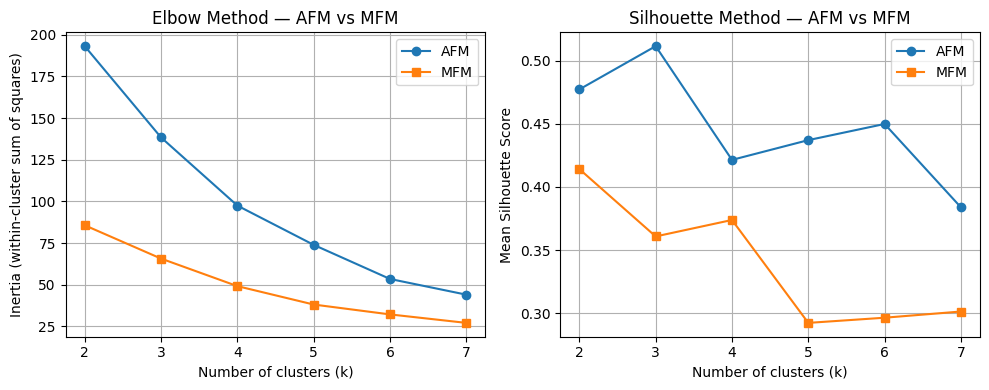

Suggested k (AFM): 3  |  Suggested k (MFM): 2


In [ ]:
# === Step 4a: Cluster tuning (Elbow + Silhouette) ===
# Run this before Step 4’s final clustering to decide good k values.

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- Load features ----
csv_path = "/content/afm_mfm_features_full_fixed2nm.csv"
df = pd.read_csv(csv_path)

# ---- Select features ----
afm_cols = [c for c in ["Ra","Rq","Skew","Kurt","corr_len_nm","psd_slope","anisotropy"] if c in df.columns]
mfm_cols = [c for c in ["mfm_mean","mfm_std","edge_density","domain_size_nm"] if c in df.columns]
print("AFM features:", afm_cols)
print("MFM features:", mfm_cols)

X_afm = StandardScaler().fit_transform(df[afm_cols])
X_mfm = StandardScaler().fit_transform(df[mfm_cols])

# ---- Define k range ----
k_values = range(2, 8)   # try 2–7 clusters (adjust as needed)
inertia_afm, inertia_mfm = [], []
sil_afm, sil_mfm = [], []

for k in k_values:
    # AFM clustering
    km_a = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_a = km_a.fit_predict(X_afm)
    inertia_afm.append(km_a.inertia_)
    sil_afm.append(silhouette_score(X_afm, labels_a) if k > 1 else np.nan)

    # MFM clustering
    km_m = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_m = km_m.fit_predict(X_mfm)
    inertia_mfm.append(km_m.inertia_)
    sil_mfm.append(silhouette_score(X_mfm, labels_m) if k > 1 else np.nan)

# ---- Plot Elbow (Inertia) ----
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(k_values, inertia_afm, '-o', label='AFM')
plt.plot(k_values, inertia_mfm, '-s', label='MFM')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method — AFM vs MFM")
plt.legend(); plt.grid(True)

# ---- Plot Silhouette ----
plt.subplot(1,2,2)
plt.plot(k_values, sil_afm, '-o', label='AFM')
plt.plot(k_values, sil_mfm, '-s', label='MFM')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Method — AFM vs MFM")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Print suggested k values ----
best_afm = k_values[int(np.nanargmax(sil_afm))]
best_mfm = k_values[int(np.nanargmax(sil_mfm))]
print(f"Suggested k (AFM): {best_afm}  |  Suggested k (MFM): {best_mfm}")


Loaded features: (43, 16)
AFM features: ['Ra', 'Rq', 'Skew', 'Kurt', 'corr_len_nm', 'psd_slope', 'anisotropy']
MFM features: ['mfm_mean', 'mfm_std', 'edge_density', 'domain_size_nm']


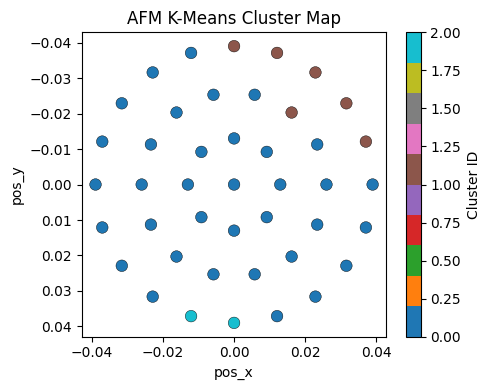

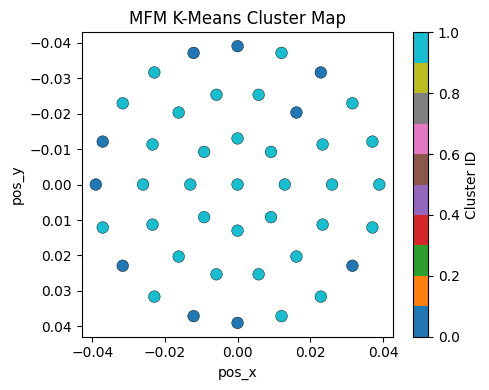

Explained variance ratio: [0.418 0.198]


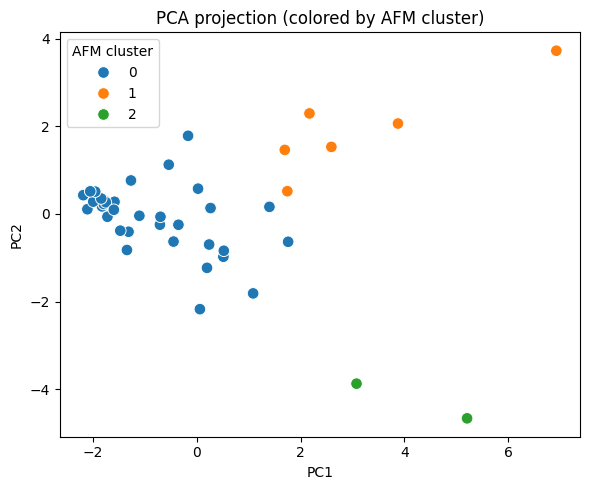

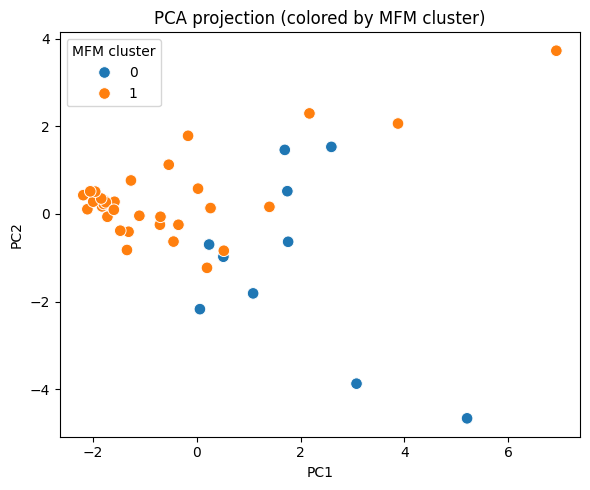

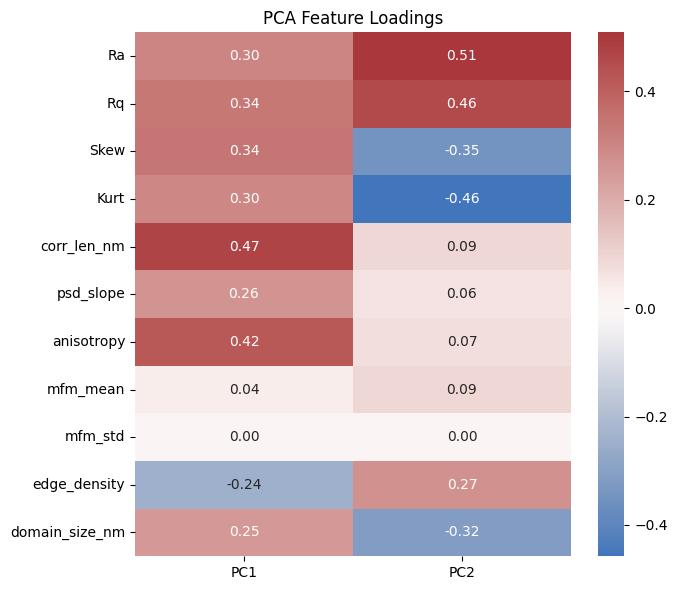


Cluster correspondence (AFM vs MFM):


MFM_cluster,0,1
AFM_cluster,,
0,5,30
1,3,3
2,2,0


Saved enriched feature table: /content/afm_mfm_features_clustered.csv


In [ ]:
# === Step 4: Unsupervised Learning – K-Means + PCA ===
# Works directly on your fixed-2 nm feature CSV from Step 2 or Step 3.

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---- Load feature table ----
csv_path = "/content/afm_mfm_features_full_fixed2nm.csv"   # batch dataset
df = pd.read_csv(csv_path)
print(f"Loaded features: {df.shape}")

# ---- Define feature groups ----
afm_cols = [c for c in ["Ra","Rq","Skew","Kurt","corr_len_nm","psd_slope","anisotropy"] if c in df.columns]
mfm_cols = [c for c in ["mfm_mean","mfm_std","edge_density","domain_size_nm"] if c in df.columns]
print("AFM features:", afm_cols)
print("MFM features:", mfm_cols)

# =========================================================
# 4.1  K-Means clustering (AFM + MFM separately)
# =========================================================
scaler_afm = StandardScaler()
X_afm = scaler_afm.fit_transform(df[afm_cols])
scaler_mfm = StandardScaler()
X_mfm = scaler_mfm.fit_transform(df[mfm_cols])

# You can tune k using an elbow or silhouette plot later; start with k=3
k_afm = 3
k_mfm = 2

km_afm = KMeans(n_clusters=k_afm, n_init=20, random_state=42)
km_mfm = KMeans(n_clusters=k_mfm, n_init=20, random_state=42)

df["AFM_cluster"] = km_afm.fit_predict(X_afm)
df["MFM_cluster"] = km_mfm.fit_predict(X_mfm)

# =========================================================
# 4.2  Visualize cluster maps spatially
# =========================================================
def plot_spatial_clusters(col, title):
    if not {"pos_x","pos_y"}.issubset(df.columns): return
    plt.figure(figsize=(5,4))
    sc = plt.scatter(df["pos_x"], df["pos_y"], c=df[col], cmap="tab10",
                     s=70, edgecolors="k", linewidth=0.3)
    plt.xlabel("pos_x"); plt.ylabel("pos_y"); plt.title(title)
    plt.gca().invert_yaxis()
    plt.colorbar(sc, label="Cluster ID")
    plt.tight_layout(); plt.show()

plot_spatial_clusters("AFM_cluster", "AFM K-Means Cluster Map")
plot_spatial_clusters("MFM_cluster", "MFM K-Means Cluster Map")

# =========================================================
# 4.3  PCA (combined AFM + MFM features)
# =========================================================
combined_cols = afm_cols + mfm_cols
scaler_all = StandardScaler()
X_all = scaler_all.fit_transform(df[combined_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)
df["PC1"], df["PC2"] = X_pca[:,0], X_pca[:,1]

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

# PCA scatter by AFM clusters
plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1", y="PC2", hue="AFM_cluster", data=df, palette="tab10", s=70)
plt.title("PCA projection (colored by AFM cluster)")
plt.legend(title="AFM cluster")
plt.tight_layout(); plt.show()

# PCA scatter by MFM clusters
plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1", y="PC2", hue="MFM_cluster", data=df, palette="tab10", s=70)
plt.title("PCA projection (colored by MFM cluster)")
plt.legend(title="MFM cluster")
plt.tight_layout(); plt.show()

# =========================================================
# 4.4  PCA loadings (feature contributions)
# =========================================================
loadings = pd.DataFrame(pca.components_.T, index=combined_cols, columns=["PC1","PC2"])
plt.figure(figsize=(7,6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("PCA Feature Loadings")
plt.tight_layout(); plt.show()

# =========================================================
# 4.5  Cluster correspondence (AFM ↔ MFM)
# =========================================================
ct = pd.crosstab(df["AFM_cluster"], df["MFM_cluster"])
print("\nCluster correspondence (AFM vs MFM):")
display(ct)

# Save enriched table for supervised learning (Step 5)
out_csv = "/content/afm_mfm_features_clustered.csv"
df.to_csv(out_csv, index=False)
print("Saved enriched feature table:", out_csv)


#Supervised Learning (LDA, QDA, MLR)

Purpose:
Cluster scans into regions of similar morphology or magnetism and reduce feature dimensionality.

What it does:
Applies K-Means clustering separately to AFM and MFM features.
Uses PCA to capture dominant variance directions and visualize all samples in a 2-D feature space.
Creates spatial cluster maps and PCA scatter plots colored by cluster labels.

Guides:
Highlights compositional or structural zones on the film and reveals which features (via PCA loadings) drive the main trends.
These PCA loadings inform which AFM descriptors to prioritize for supervised modeling.

Loaded: (43, 20)
AFM: ['Ra', 'Rq', 'Skew', 'Kurt', 'corr_len_nm', 'psd_slope', 'anisotropy']
MFM: ['mfm_mean', 'mfm_std', 'edge_density', 'domain_size_nm']
Top AFM by PCA loadings: ['Ra', 'corr_len_nm', 'Kurt', 'Rq']

AFM↔MFM cluster correspondence:


MFM_cluster,0,1
AFM_cluster,,
0,5,30
1,3,3
2,2,0



LDA accuracy: 0.846
LDA report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.83      1.00      0.91        10

    accuracy                           0.85        13
   macro avg       0.92      0.67      0.70        13
weighted avg       0.87      0.85      0.81        13



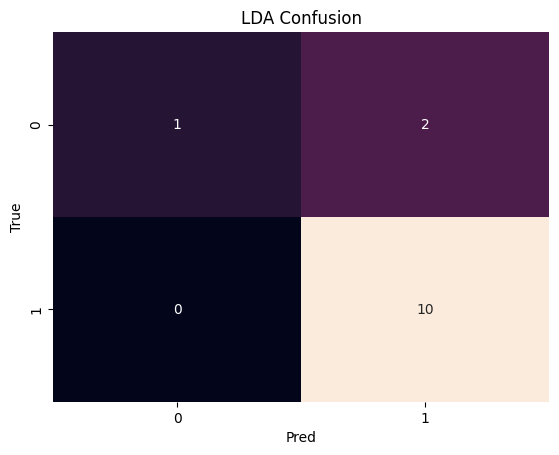

QDA accuracy: 0.692
QDA report:
               precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.88      0.70      0.78        10

    accuracy                           0.69        13
   macro avg       0.64      0.68      0.64        13
weighted avg       0.77      0.69      0.71        13



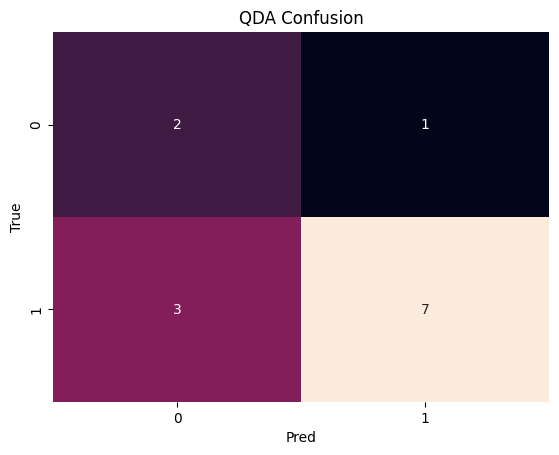

ROC-AUC not computed: y should be a 1d array, got an array of shape (13, 2) instead.
MLR: mfm_std from AFM  R^2=1.000  RMSE=0


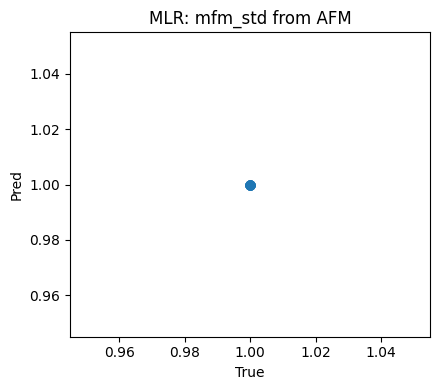

MLR: domain_size_nm from AFM  R^2=-0.221  RMSE=39.9


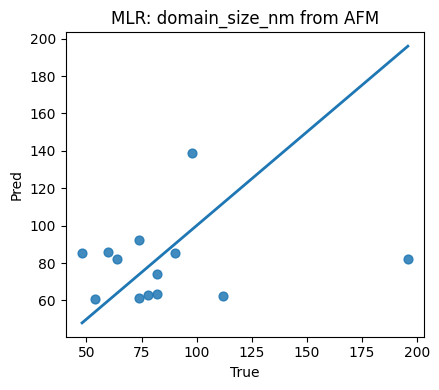

Saved predictions to: /content/afm_mfm_step5_predictions_fixed.csv


In [ ]:
# === Step 5 (FIXED): supervised learning with stable indexing ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             r2_score, mean_squared_error, roc_auc_score)

# ---------------- Load enriched dataset from Step 4 ----------------
csv_path = "/content/afm_mfm_features_clustered.csv"
df = pd.read_csv(csv_path)
print("Loaded:", df.shape)

afm_cols = [c for c in ["Ra","Rq","Skew","Kurt","corr_len_nm","psd_slope","anisotropy"] if c in df.columns]
mfm_cols = [c for c in ["mfm_mean","mfm_std","edge_density","domain_size_nm"] if c in df.columns]
combined_cols = afm_cols + mfm_cols
print("AFM:", afm_cols)
print("MFM:", mfm_cols)

# ---------------- Use PCA loadings to pick AFM features ----------------
scaler_all = StandardScaler()
X_all = scaler_all.fit_transform(df[combined_cols])
pca = PCA(n_components=2, random_state=42).fit(X_all)
loadings = pd.DataFrame(pca.components_.T, index=combined_cols, columns=["PC1","PC2"])

k = 4  # keep top-k AFM features by |loading|
ranked_afm = (loadings.loc[afm_cols].abs()
              .assign(max_abs=lambda d: d[["PC1","PC2"]].max(axis=1))
              .sort_values("max_abs", ascending=False))
top_afm_cols = ranked_afm.head(k).index.tolist()
print("Top AFM by PCA loadings:", top_afm_cols)

# ---------------- Cluster correspondence sanity check ----------------
if {"AFM_cluster","MFM_cluster"}.issubset(df.columns):
    ct = pd.crosstab(df["AFM_cluster"], df["MFM_cluster"])
    print("\nAFM↔MFM cluster correspondence:"); display(ct)

# ---------------- Feature matrix (X) and targets (y) ----------------
X_cols = top_afm_cols  # or use afm_cols if you prefer all features
X = StandardScaler().fit_transform(df[X_cols].values)

y_cls = df["MFM_cluster"].values if "MFM_cluster" in df.columns else None
y_reg_std = df["mfm_std"].values if "mfm_std" in df.columns else None
y_reg_dom = df["domain_size_nm"].values if "domain_size_nm" in df.columns else None

# ---------------- Single, robust index split (fixes your error) ----------------
n = len(df)
row_idx = np.arange(n)

# Stratify split if classification target exists and has >=2 classes
strat = y_cls if (y_cls is not None and len(np.unique(y_cls)) >= 2) else None
train_idx, test_idx = train_test_split(row_idx, test_size=0.30, random_state=42, stratify=strat)

Xtr, Xte = X[train_idx], X[test_idx]
if y_cls is not None:
    ytr_c, yte_c = y_cls[train_idx], y_cls[test_idx]
if y_reg_std is not None:
    ytr_r1, yte_r1 = y_reg_std[train_idx], y_reg_std[test_idx]
if y_reg_dom is not None:
    ytr_r2, yte_r2 = y_reg_dom[train_idx], y_reg_dom[test_idx]

# ---------------- Classification: LDA / QDA (predict MFM_cluster) ----------------
out_df = df.copy()
if y_cls is not None:
    # LDA
    lda = LDA()
    lda.fit(Xtr, ytr_c)
    ypred_lda = lda.predict(Xte)
    acc_lda = accuracy_score(yte_c, ypred_lda)
    print(f"\nLDA accuracy: {acc_lda:.3f}")
    print("LDA report:\n", classification_report(yte_c, ypred_lda))
    cm_lda = confusion_matrix(yte_c, ypred_lda)
    sns.heatmap(cm_lda, annot=True, fmt="d", cbar=False); plt.title("LDA Confusion"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()
    # write predictions using test indices
    out_df["LDA_pred"] = np.nan
    out_df.loc[test_idx, "LDA_pred"] = ypred_lda

    # QDA (lightly regularized)
    qda = QDA(reg_param=1e-3)
    qda.fit(Xtr, ytr_c)
    ypred_qda = qda.predict(Xte)
    acc_qda = accuracy_score(yte_c, ypred_qda)
    print(f"QDA accuracy: {acc_qda:.3f}")
    print("QDA report:\n", classification_report(yte_c, ypred_qda))
    cm_qda = confusion_matrix(yte_c, ypred_qda)
    sns.heatmap(cm_qda, annot=True, fmt="d", cbar=False); plt.title("QDA Confusion"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()
    out_df["QDA_pred"] = np.nan
    out_df.loc[test_idx, "QDA_pred"] = ypred_qda

    # Optional multiclass ROC-AUC (macro OVR) for LDA if proba available
    if hasattr(lda, "predict_proba"):
        try:
            proba = lda.predict_proba(Xte)
            roc_macro = roc_auc_score(yte_c, proba, multi_class="ovr", average="macro")
            print(f"LDA ROC-AUC (macro, OVR): {roc_macro:.3f}")
        except Exception as e:
            print("ROC-AUC not computed:", e)

# ---------------- Regression: MLR (predict mfm_std, domain_size_nm) ----------------
def eval_reg(model, Xtr, ytr, Xte, yte, label):
    model.fit(Xtr, ytr)
    yhat = model.predict(Xte)
    r2  = r2_score(yte, yhat)
    rmse = np.sqrt(mean_squared_error(yte, yhat))
    print(f"{label}  R^2={r2:.3f}  RMSE={rmse:.3g}")
    plt.figure(figsize=(4.5,4))
    plt.scatter(yte, yhat, s=40, alpha=0.85)
    lims = [np.nanmin([yte.min(), yhat.min()]), np.nanmax([yte.max(), yhat.max()])]
    xs = np.linspace(lims[0], lims[1], 50)
    plt.plot(xs, xs, linewidth=2)
    plt.xlabel("True"); plt.ylabel("Pred"); plt.title(label)
    plt.tight_layout(); plt.show()
    return yhat

if y_reg_std is not None:
    lr_std = LinearRegression()
    yhat_std = eval_reg(lr_std, Xtr, ytr_r1, Xte, yte_r1, "MLR: mfm_std from AFM")
    out_df["MLR_mfm_std_pred"] = np.nan
    out_df.loc[test_idx, "MLR_mfm_std_pred"] = yhat_std

if y_reg_dom is not None:
    lr_dom = LinearRegression()
    yhat_dom = eval_reg(lr_dom, Xtr, ytr_r2, Xte, yte_r2, "MLR: domain_size_nm from AFM")
    out_df["MLR_domain_size_pred"] = np.nan
    out_df.loc[test_idx, "MLR_domain_size_pred"] = yhat_dom

# ---------------- Save with predictions ----------------
out_path = "/content/afm_mfm_step5_predictions_fixed.csv"
out_df.to_csv(out_path, index=False)
print("Saved predictions to:", out_path)


#Spatial Maps & Trend Surfaces

Purpose:
Predict magnetic behavior from surface morphology.

What it does:
Uses PCA-selected AFM features as predictors.
LDA / QDA: classify samples into MFM cluster labels (categorical magnetism).
MLR: regress continuous magnetic responses (mfm_std, domain_size_nm).
Reports accuracy, confusion matrices, ROC-AUC (classification) and R² / RMSE (regression).

Guides:
Quantifies how well topographic and texture features explain the observed magnetic domain patterns.

Loaded: /content/afm_mfm_step5_predictions_fixed.csv shape: (43, 24)
Will map: ['Rq', 'anisotropy', 'mfm_std', 'edge_density', 'domain_size_nm', 'PC1', 'PC2']


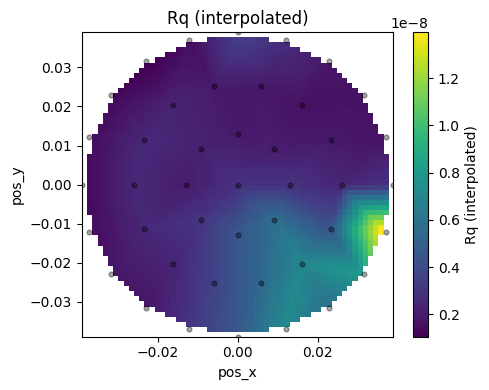

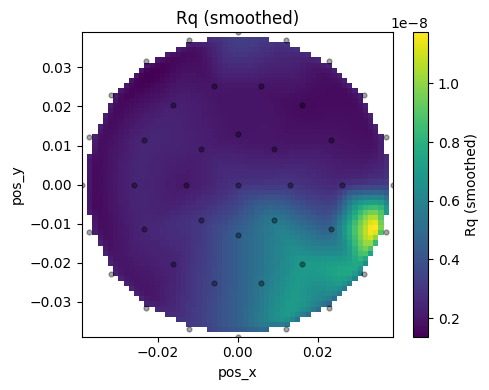

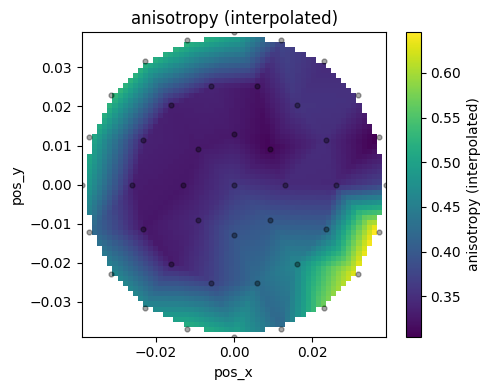

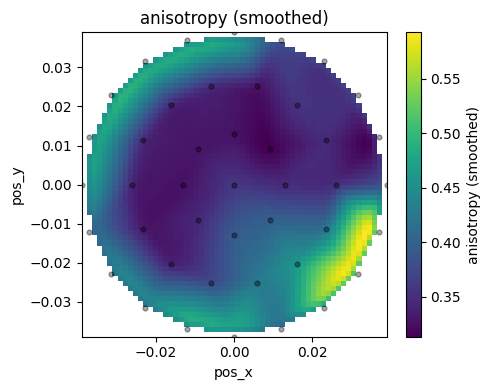

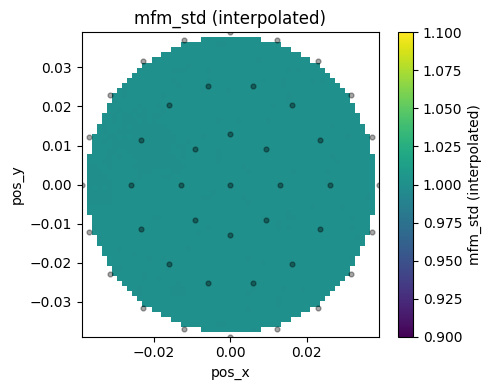

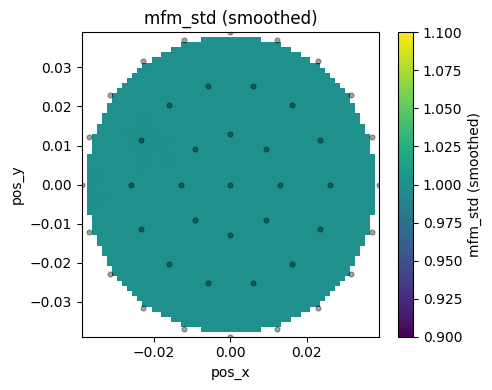

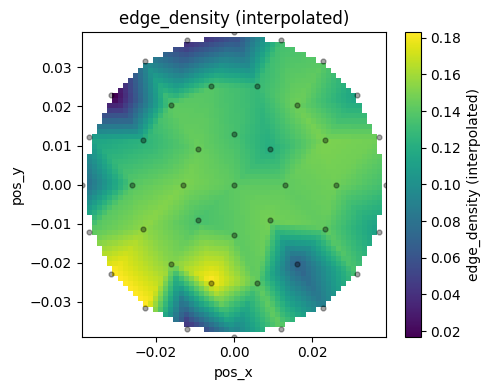

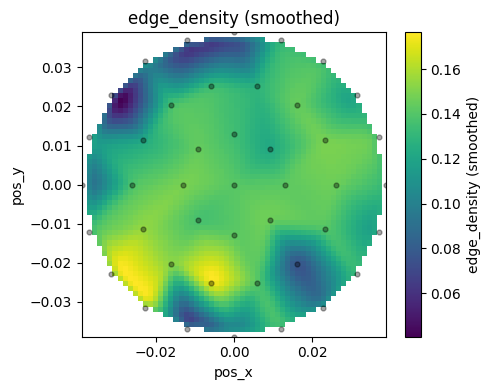

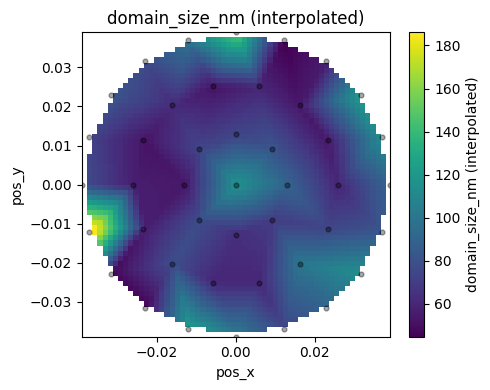

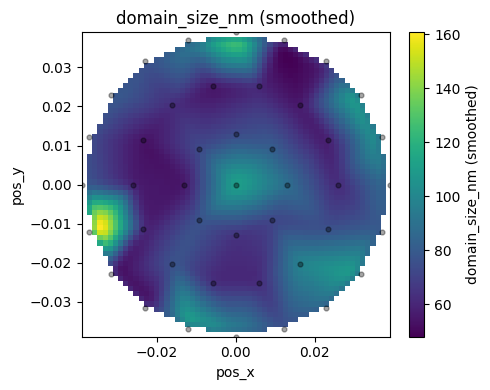

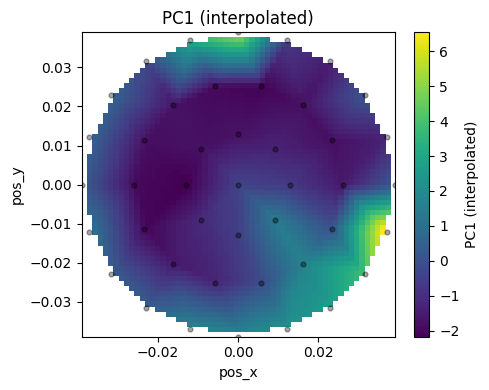

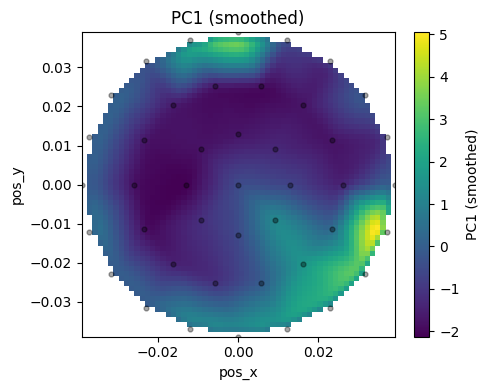

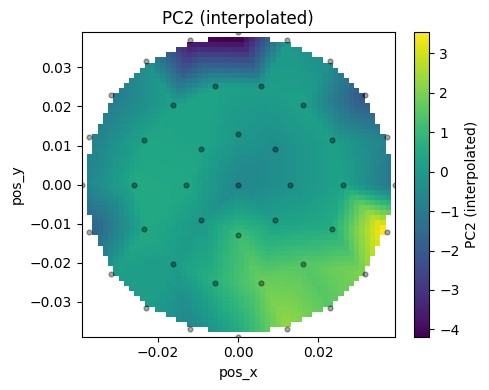

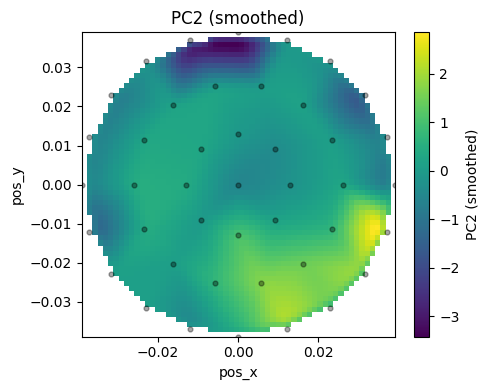

In [ ]:
# === Step 6A: Spatial maps & trend surfaces ===
# Interpolates scattered (pos_x, pos_y) onto a regular grid, smooths, and visualizes
# key AFM/MFM fields and PCA components (if present).

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# ---- Load data (predictions file if present; else features file) ----
paths = [
    "/content/afm_mfm_step5_predictions_fixed.csv",
    "/content/afm_mfm_features_full_fixed2nm.csv",
]
df = None
for p in paths:
    try:
        df = pd.read_csv(p)
        print("Loaded:", p, "shape:", df.shape)
        break
    except Exception:
        pass
if df is None:
    raise FileNotFoundError("Run Steps 4–5 first to generate the input CSVs.")

assert {"pos_x","pos_y"}.issubset(df.columns), "pos_x/pos_y missing."

# ---- Choose features to map (edit as needed) ----
fields_to_map = [c for c in [
    "Rq","anisotropy","mfm_std","edge_density","domain_size_nm","PC1","PC2"
] if c in df.columns]

print("Will map:", fields_to_map)

# ---- Build a regular grid covering the sampling envelope ----
x = df["pos_x"].values
y = df["pos_y"].values

nx = ny = 60  # grid density (increase if you want finer maps)
gx = np.linspace(np.min(x), np.max(x), nx)
gy = np.linspace(np.min(y), np.max(y), ny)
GX, GY = np.meshgrid(gx, gy)

def make_map(z, smooth_sigma=1.0):
    Z = griddata(points=np.c_[x, y], values=z, xi=(GX, GY), method="linear")
    # Optional gentle smoothing (NaN-safe)
    Zs = Z.copy()
    mask = np.isnan(Zs)
    # fill NaNs temporarily for smoothing, then re-mask
    Zs_f = Zs.copy()
    Zs_f[mask] = np.nanmean(Zs) if np.isfinite(np.nanmean(Zs)) else 0.0
    Zs_f = gaussian_filter(Zs_f, sigma=smooth_sigma)
    Zs = np.where(mask, np.nan, Zs_f)
    return Z, Zs

def plot_map(Z, title, cmap="viridis", vmin=None, vmax=None):
    plt.figure(figsize=(5,4))
    im = plt.imshow(Z, origin="lower",
                    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
                    aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.scatter(x, y, s=12, c="k", alpha=0.35)  # sampling points
    plt.xlabel("pos_x"); plt.ylabel("pos_y")
    plt.title(title)
    cb = plt.colorbar(im); cb.set_label(title)
    plt.tight_layout()
    plt.show()

# ---- Produce maps for each selected field ----
for col in fields_to_map:
    z = df[col].values
    Z, Zs = make_map(z, smooth_sigma=1.0)  # tweak sigma if you want more/less smoothing
    plot_map(Z, f"{col} (interpolated)")
    plot_map(Zs, f"{col} (smoothed)")


#Spatial Diagnostics

Purpose:
Reveal spatial organization and model shortcomings across the combinatorial library.

What it does:
Interpolates AFM/MFM features and model residuals onto a regular 2-D grid.
Produces smoothed trend maps to visualize compositional gradients.
Calculates Moran’s I to test spatial autocorrelation in residuals (indicating missing spatial predictors).

Guides:
Shows whether magnetic responses vary systematically across the film and whether the models capture that variation.

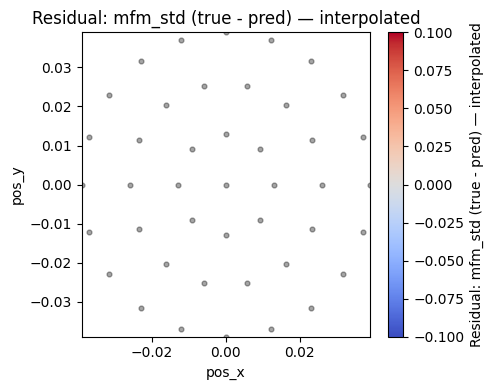

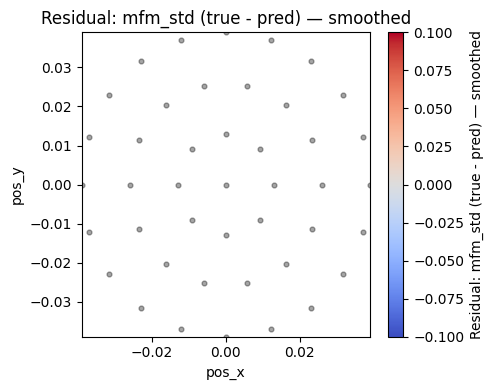

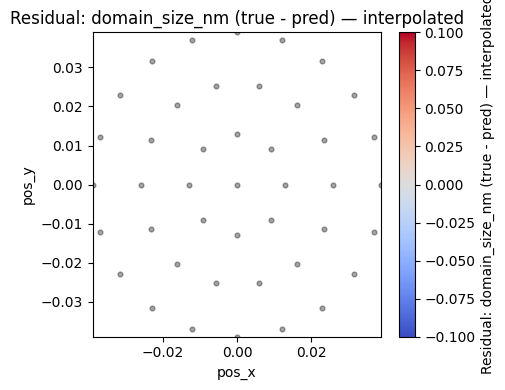

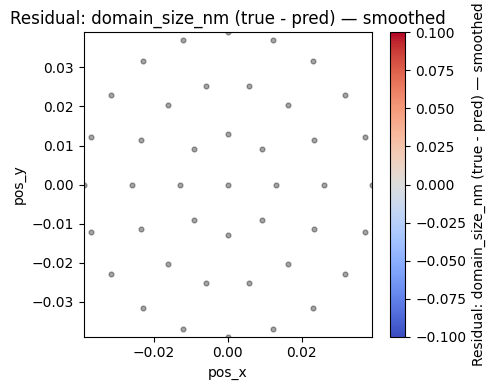

Moran's I for resid_mfm_std (k=6): nan
Moran's I for resid_domain_size_nm (k=6): -0.125


In [ ]:
# === Step 6B: Spatial diagnostics (model residuals + Moran's I) ===
# Maps residuals from Step-5 regressions and quantifies spatial autocorrelation.

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# ---- Load predictions file (Step 5 output) ----
df = pd.read_csv("/content/afm_mfm_step5_predictions_fixed.csv")
assert {"pos_x","pos_y"}.issubset(df.columns)

# ---- Residuals for continuous targets (if available) ----
residual_specs = []
if {"mfm_std","MLR_mfm_std_pred"}.issubset(df.columns):
    df["resid_mfm_std"] = df["mfm_std"] - df["MLR_mfm_std_pred"]
    residual_specs.append(("resid_mfm_std", "Residual: mfm_std (true - pred)"))

if {"domain_size_nm","MLR_domain_size_pred"}.issubset(df.columns):
    df["resid_domain_size_nm"] = df["domain_size_nm"] - df["MLR_domain_size_pred"]
    residual_specs.append(("resid_domain_size_nm", "Residual: domain_size_nm (true - pred)"))

# ---- Helper to grid + plot (reuse from 6A) ----
x = df["pos_x"].values; y = df["pos_y"].values
nx = ny = 60
gx = np.linspace(np.min(x), np.max(x), nx)
gy = np.linspace(np.min(y), np.max(y), ny)
GX, GY = np.meshgrid(gx, gy)

def make_map(z, smooth_sigma=1.0):
    Z = griddata(points=np.c_[x, y], values=z, xi=(GX, GY), method="linear")
    Zs = Z.copy()
    mask = np.isnan(Zs)
    Zs_f = Zs.copy()
    Zs_f[mask] = np.nanmean(Zs) if np.isfinite(np.nanmean(Zs)) else 0.0
    Zs_f = gaussian_filter(Zs_f, sigma=smooth_sigma)
    Zs = np.where(mask, np.nan, Zs_f)
    return Z, Zs

def plot_map(Z, title, cmap="coolwarm"):
    plt.figure(figsize=(5,4))
    vabs = np.nanmax(np.abs(Z))
    im = plt.imshow(Z, origin="lower",
                    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
                    aspect="auto", cmap=cmap, vmin=-vabs, vmax=vabs)
    plt.scatter(x, y, s=12, c="k", alpha=0.35)
    plt.xlabel("pos_x"); plt.ylabel("pos_y")
    plt.title(title)
    cb = plt.colorbar(im); cb.set_label(title)
    plt.tight_layout(); plt.show()

for col, title in residual_specs:
    Z, Zs = make_map(df[col].values, smooth_sigma=1.0)
    plot_map(Z, f"{title} — interpolated")
    plot_map(Zs, f"{title} — smoothed")

# ---- Moran's I (lightweight) on residuals using k-NN graph ----
def morans_I_knn(xy, values, k=6):
    """Compute Moran's I with a symmetric k-NN weight matrix (row-standardized)."""
    vals = np.asarray(values, dtype=float)
    m = np.isfinite(vals)
    xy = np.asarray(xy)[m]
    vals = vals[m]
    if len(vals) < k+2: return np.nan

    # Build kNN graph
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k+1, algorithm="auto").fit(xy)
    dists, idxs = nn.kneighbors(xy)
    # drop self neighbor (dist=0, first col)
    idxs = idxs[:, 1:]

    n = len(vals)
    z = vals - vals.mean()
    W = np.zeros((n, n), dtype=float)
    for i in range(n):
        W[i, idxs[i]] = 1.0
    # Symmetrize & row-standardize
    W = np.maximum(W, W.T)
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums==0] = 1.0
    W = W / row_sums

    num = 0.0
    for i in range(n):
        for j in range(n):
            if W[i, j] > 0:
                num += W[i, j] * z[i] * z[j]
    den = np.sum(z**2)
    I = (n / np.sum(W)) * (num / den) if den > 0 else np.nan
    return I

for col, _ in residual_specs:
    xy = np.c_[df["pos_x"].values, df["pos_y"].values]
    I = morans_I_knn(xy, df[col].values, k=6)
    print(f"Moran's I for {col} (k=6): {I:.3f}")


#Summary and Reporting

Purpose:
Reveal spatial organization and model shortcomings across the combinatorial library.

What it does:
Interpolates AFM/MFM features and model residuals onto a regular 2-D grid.
Produces smoothed trend maps to visualize compositional gradients.
Calculates Moran’s I to test spatial autocorrelation in residuals (indicating missing spatial predictors).

Guides:
Shows whether magnetic responses vary systematically across the film and whether the models capture that variation.

In [ ]:
# === Step 7 (ROBUST): Results Summary & Report Export ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# Load main DF (predictions from Step 5) and clustered features
# ------------------------------------------------------------
pred_path = "/content/afm_mfm_step5_predictions_fixed.csv"
feat_path = "/content/afm_mfm_features_full_fixed2nm.csv"

df = pd.read_csv(pred_path)
print("Loaded predictions:", df.shape)

try:
    df_clust = pd.read_csv("/content/afm_mfm_features_clustered.csv")
    print("Loaded clusters:", df_clust.shape)
except Exception:
    df_clust = df.copy()

# ------------------------------------------------------------
# 7.1  Metrics with NaN-safe handling
# ------------------------------------------------------------
metrics = {}

def nan_safe_accuracy(true_col, pred_col, name):
    if not {true_col, pred_col}.issubset(df.columns):
        return
    m = df[[true_col, pred_col]].dropna()
    if len(m) == 0:
        print(f"Skipping {name}: no valid rows.")
        return
    acc = (m[true_col].astype(int) == m[pred_col].astype(int)).mean()
    metrics[name] = float(acc)

def nan_safe_regression(y_true_col, y_pred_col, name_prefix):
    from sklearn.metrics import r2_score, mean_squared_error
    if not {y_true_col, y_pred_col}.issubset(df.columns):
        return
    m = df[[y_true_col, y_pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(m) < 3:
        print(f"Skipping {name_prefix}: insufficient valid rows (<3).")
        return
    r2 = r2_score(m[y_true_col].values, m[y_pred_col].values)
    rmse = float(np.sqrt(mean_squared_error(m[y_true_col].values, m[y_pred_col].values)))
    metrics[f"{name_prefix}_R2"] = float(r2)
    metrics[f"{name_prefix}_RMSE"] = rmse

# Classification metrics (only where predictions exist)
nan_safe_accuracy("MFM_cluster", "LDA_pred", "LDA_Accuracy")
nan_safe_accuracy("MFM_cluster", "QDA_pred", "QDA_Accuracy")

# Regression metrics (NaN-safe)
nan_safe_regression("mfm_std", "MLR_mfm_std_pred", "MLR_mfm_std")
nan_safe_regression("domain_size_nm", "MLR_domain_size_pred", "MLR_domain")

# ------------------------------------------------------------
# 7.2  AFM↔MFM correlations (NaN-safe)
# ------------------------------------------------------------
afm_cols = [c for c in ["Ra","Rq","Skew","Kurt","corr_len_nm","psd_slope","anisotropy"] if c in df.columns]
mfm_cols = [c for c in ["mfm_mean","mfm_std","edge_density","domain_size_nm"] if c in df.columns]
corrmat = df[afm_cols + mfm_cols].corr(numeric_only=True).loc[afm_cols, mfm_cols]

plt.figure(figsize=(8,6))
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("AFM ↔ MFM Correlation Matrix")
plt.tight_layout()
Path("/content").mkdir(parents=True, exist_ok=True)
plt.savefig("/content/fig_corr_afm_mfm.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# 7.3  Cluster correspondence heatmap (if available)
# ------------------------------------------------------------
if {"AFM_cluster","MFM_cluster"}.issubset(df_clust.columns):
    ct = pd.crosstab(df_clust["AFM_cluster"], df_clust["MFM_cluster"])
    plt.figure(figsize=(5,4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
    plt.title("Cluster Correspondence: AFM ↔ MFM")
    plt.xlabel("MFM cluster"); plt.ylabel("AFM cluster")
    plt.tight_layout()
    plt.savefig("/content/fig_cluster_correspondence.png", dpi=300)
    plt.close()

# ------------------------------------------------------------
# 7.4  Save metrics CSV
# ------------------------------------------------------------
df_metrics = pd.DataFrame(list(metrics.items()), columns=["Metric","Value"])
df_metrics.to_csv("/content/summary_metrics.csv", index=False)
print("Saved metrics:", "/content/summary_metrics.csv")
print(df_metrics)

# ------------------------------------------------------------
# 7.5  Try to make a PDF; if reportlab missing, fallback to HTML
# ------------------------------------------------------------
def export_pdf():
    try:
        import reportlab  # noqa
    except ModuleNotFoundError:
        return False

    from reportlab.lib.pagesizes import letter
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet

    pdf_path = "/content/Results_Summary_Report.pdf"
    doc = SimpleDocTemplate(pdf_path, pagesize=letter)
    styles = getSampleStyleSheet()
    flow = []

    flow.append(Paragraph("<b>Magnetic Force Microscopy Library Analysis — Summary</b>", styles["Title"]))
    flow.append(Spacer(1,12))
    for line in [
        "This report summarizes Steps 3–6 analyses:",
        "• AFM→MFM correlations",
        "• K-Means & PCA cluster outcomes",
        "• Supervised learning (LDA/QDA/MLR) metrics",
        "• Spatial residual trends and autocorrelation",
    ]:
        flow.append(Paragraph(line, styles["Normal"]))
    flow.append(Spacer(1,12))

    # Metrics table
    table_data = [["Metric","Value"]] + [[k, f"{v:.3f}"] for k, v in metrics.items()]
    t = Table(table_data, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("BACKGROUND",(0,0),(-1,0),colors.lightgrey),
        ("GRID",(0,0),(-1,-1),0.5,colors.grey),
        ("FONT",(0,0),(-1,0),"Helvetica-Bold")
    ]))
    flow.append(t); flow.append(Spacer(1,12))

    # Images if present
    for img_path, caption in [
        ("/content/fig_corr_afm_mfm.png", "AFM–MFM correlation heatmap"),
        ("/content/fig_cluster_correspondence.png", "Cluster correspondence map"),
    ]:
        if Path(img_path).exists():
            flow.append(Image(img_path, width=400, height=300))
            flow.append(Paragraph(caption, styles["Italic"]))
            flow.append(Spacer(1,12))

    doc.build(flow)
    print("Saved PDF summary:", pdf_path)
    return True

def export_html():
    html_path = "/content/Results_Summary_Report.html"
    pieces = [
        "<h1>Magnetic Force Microscopy Library Analysis — Summary</h1>",
        "<p>This report summarizes Steps 3–6 analyses:</p>",
        "<ul>",
        "<li>AFM→MFM correlations</li>",
        "<li>K-Means & PCA cluster outcomes</li>",
        "<li>Supervised learning (LDA/QDA/MLR) metrics</li>",
        "<li>Spatial residual trends and autocorrelation</li>",
        "</ul>",
        "<h2>Performance metrics</h2>",
        df_metrics.to_html(index=False),
    ]
    for img_path in ["/content/fig_corr_afm_mfm.png", "/content/fig_cluster_correspondence.png"]:
        if Path(img_path).exists():
            pieces.append(f"<br><img src='{Path(img_path).name}' width=450>")
    with open(html_path, "w") as f:
        f.write("\n".join(pieces))
    print("Saved HTML summary:", html_path)

# Try PDF; if missing reportlab, offer install or fallback
if not export_pdf():
    print("`reportlab` not found. To enable PDF export run:  !pip install reportlab")
    export_html()


Loaded predictions: (43, 24)
Loaded clusters: (43, 20)
Saved metrics: /content/summary_metrics.csv
             Metric      Value
0      LDA_Accuracy   0.846154
1      QDA_Accuracy   0.692308
2    MLR_mfm_std_R2   1.000000
3  MLR_mfm_std_RMSE   0.000000
4     MLR_domain_R2  -0.221135
5   MLR_domain_RMSE  39.896411
Saved PDF summary: /content/Results_Summary_Report.pdf
